In [3]:
# This is an example obtained from the odl repository. Not my code

In [4]:
import numpy as np
import odl


# --- Set up geometry of the problem --- #


# Reconstruction space: discretized functions on the cube
# [-20, 20]^3 with 300 samples per dimension.
reco_space = odl.uniform_discr(
    min_pt=[-20, -20, -20], max_pt=[20, 20, 20], shape=[300, 300, 300],
    dtype='float32')

In [5]:
# Make a circular cone beam geometry with flat detector
# Angles: uniformly spaced, n = 360, min = 0, max = 2 * pi
angle_partition = odl.uniform_partition(0, 2 * np.pi, 360)
# Detector: uniformly sampled, n = (512, 512), min = (-40, -40), max = (40, 40)
detector_partition = odl.uniform_partition([-40, -40], [40, 40], [512, 512])
# Geometry with large cone and fan angle and tilted axis.
geometry = odl.tomo.ConeBeamGeometry(
    angle_partition, detector_partition, src_radius=40, det_radius=40,
    axis=[1, 1, 1])

In [6]:
# --- Create Filtered Back-projection (FBP) operator --- #


# Ray transform (= forward projection).
ray_trafo = odl.tomo.RayTransform(reco_space, geometry)

# Create FBP operator using utility function
# We select a Shepp-Logan filter, and only use the lowest 80% of frequencies to
# avoid high frequency noise.
fbp = odl.tomo.fbp_op(ray_trafo,
                      filter_type='Shepp-Logan', frequency_scaling=0.8)

In [7]:
# --- Show some examples --- #


# Create a discrete Shepp-Logan phantom (modified version)
phantom = odl.phantom.shepp_logan(reco_space, modified=True)

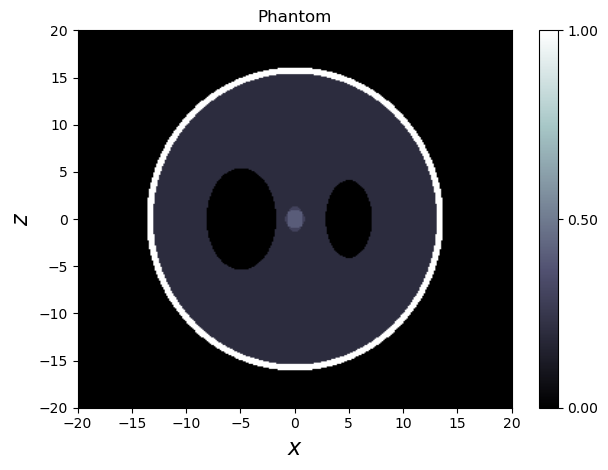

<Figure size 640x480 with 0 Axes>

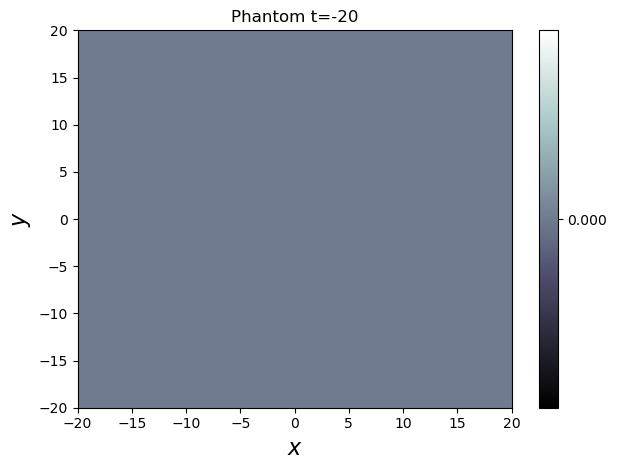

<Figure size 640x480 with 0 Axes>

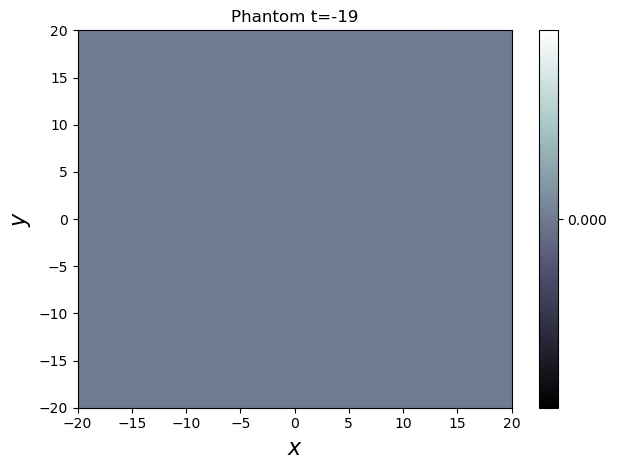

<Figure size 640x480 with 0 Axes>

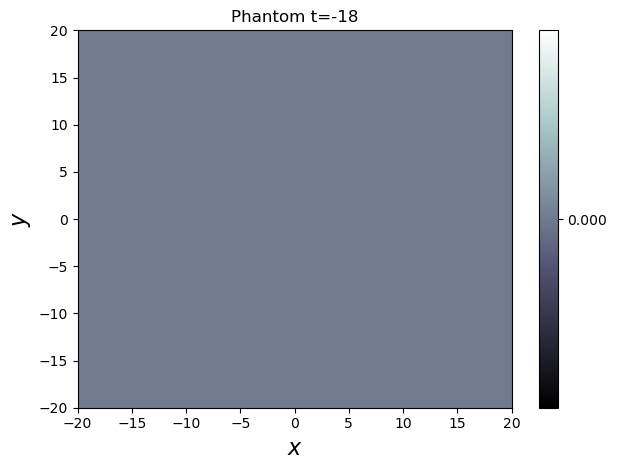

<Figure size 640x480 with 0 Axes>

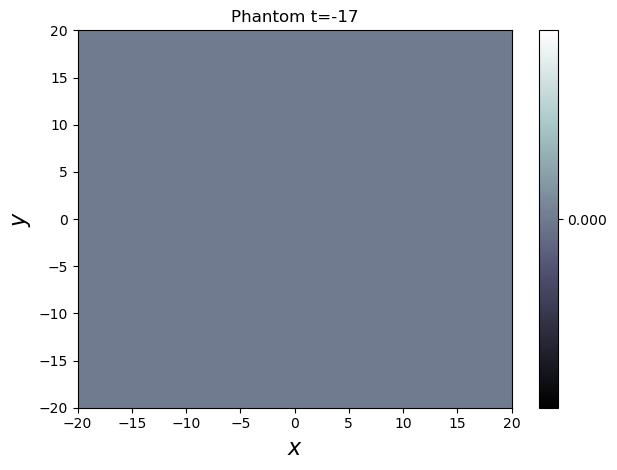

<Figure size 640x480 with 0 Axes>

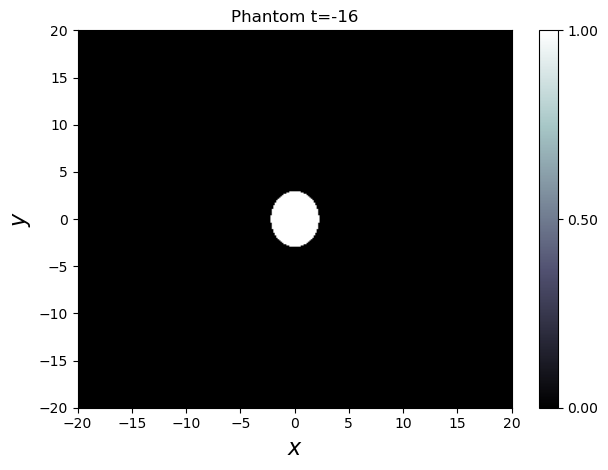

<Figure size 640x480 with 0 Axes>

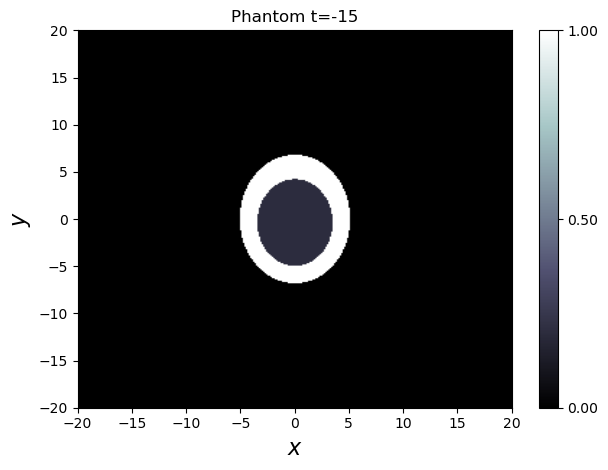

<Figure size 640x480 with 0 Axes>

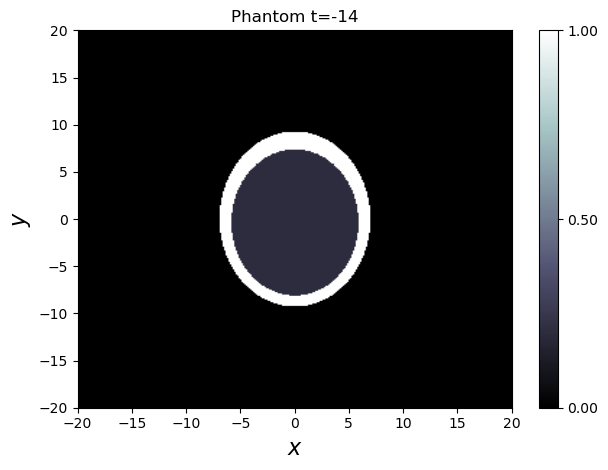

<Figure size 640x480 with 0 Axes>

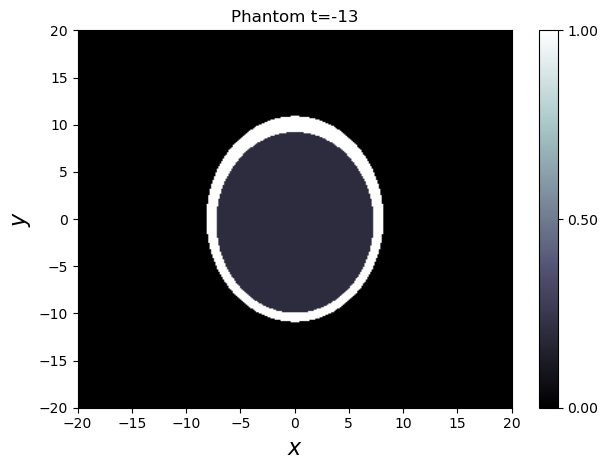

<Figure size 640x480 with 0 Axes>

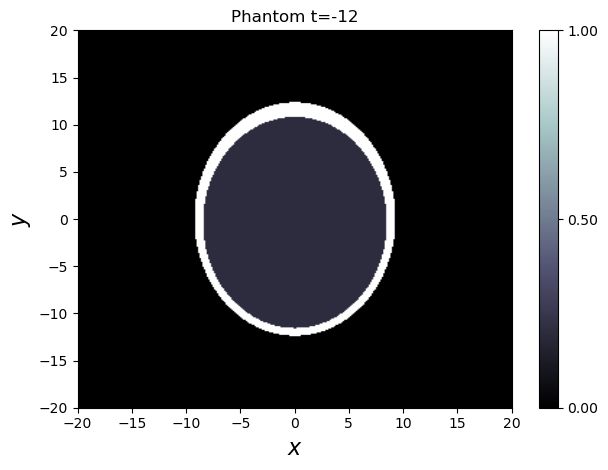

<Figure size 640x480 with 0 Axes>

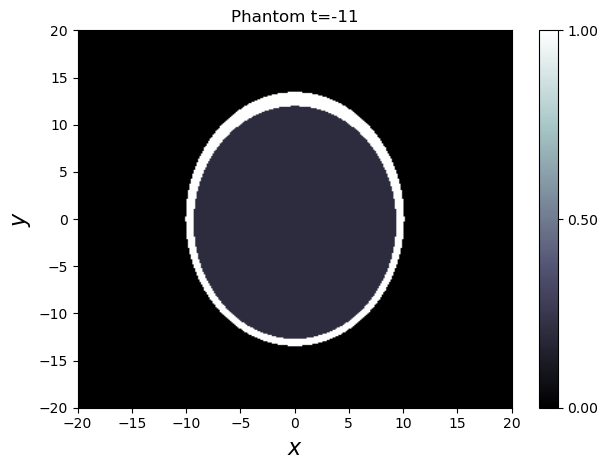

<Figure size 640x480 with 0 Axes>

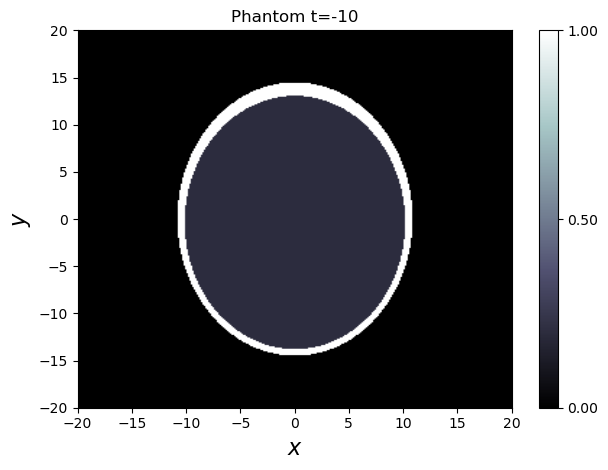

<Figure size 640x480 with 0 Axes>

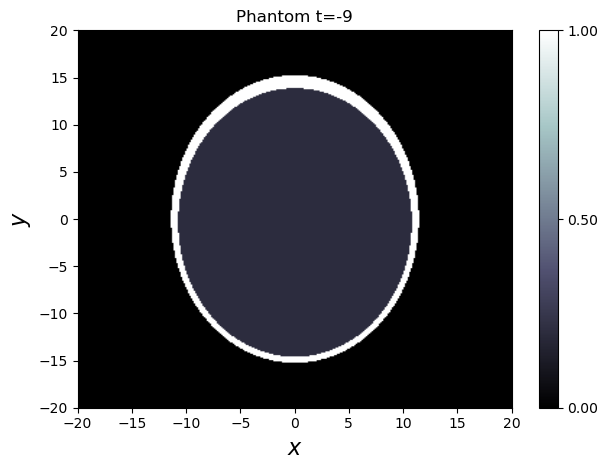

<Figure size 640x480 with 0 Axes>

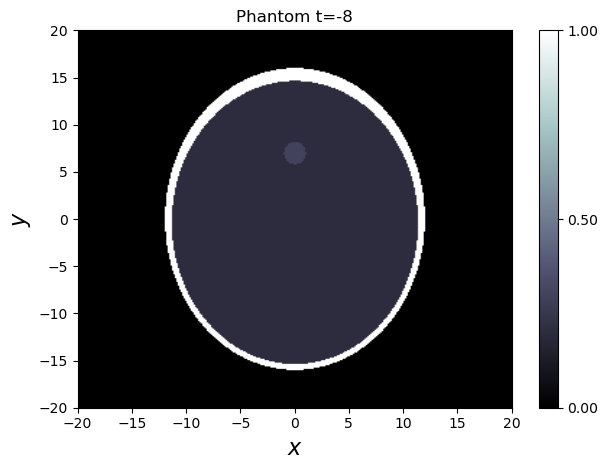

<Figure size 640x480 with 0 Axes>

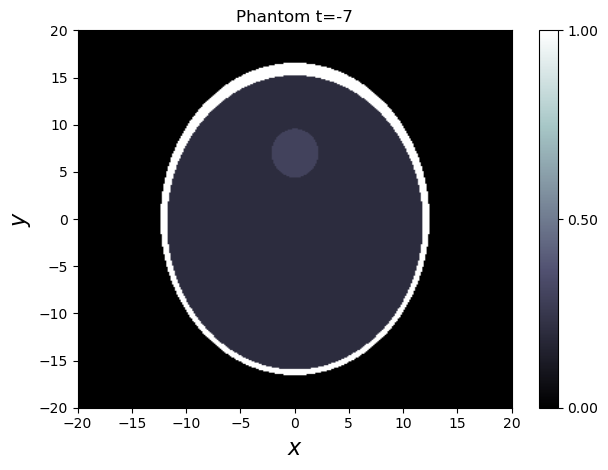

<Figure size 640x480 with 0 Axes>

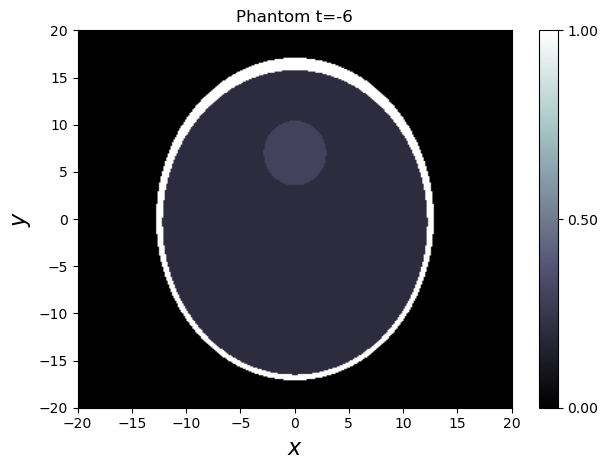

<Figure size 640x480 with 0 Axes>

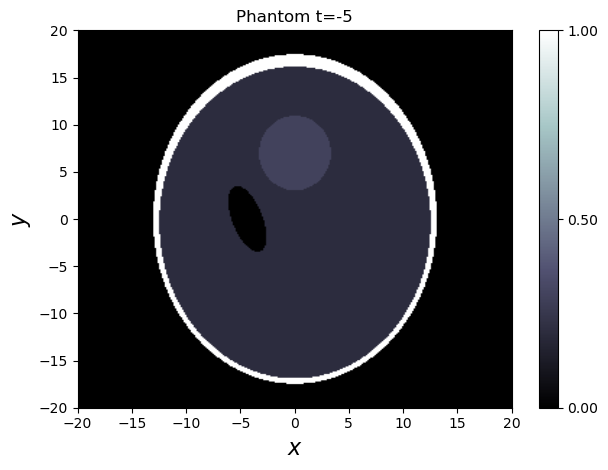

<Figure size 640x480 with 0 Axes>

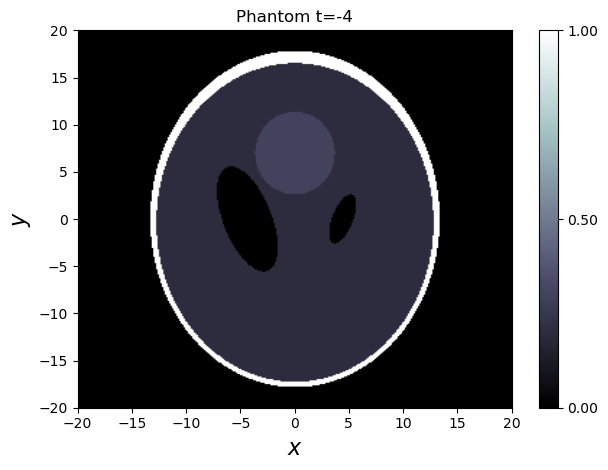

<Figure size 640x480 with 0 Axes>

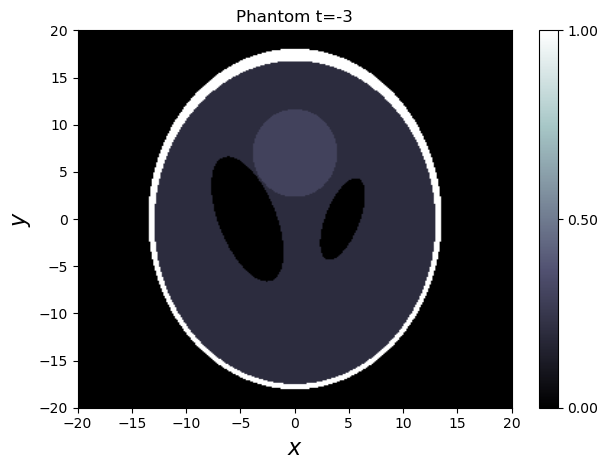

<Figure size 640x480 with 0 Axes>

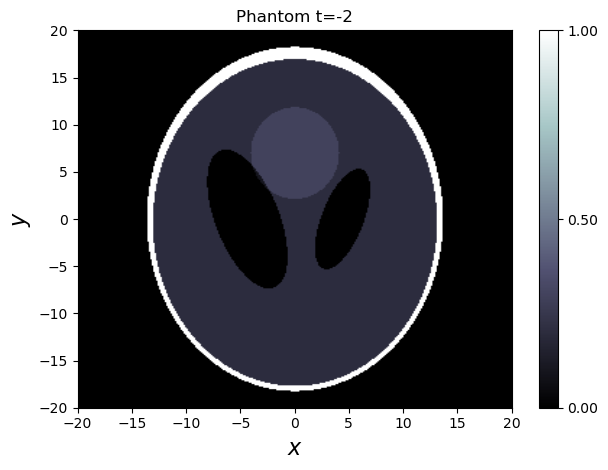

<Figure size 640x480 with 0 Axes>

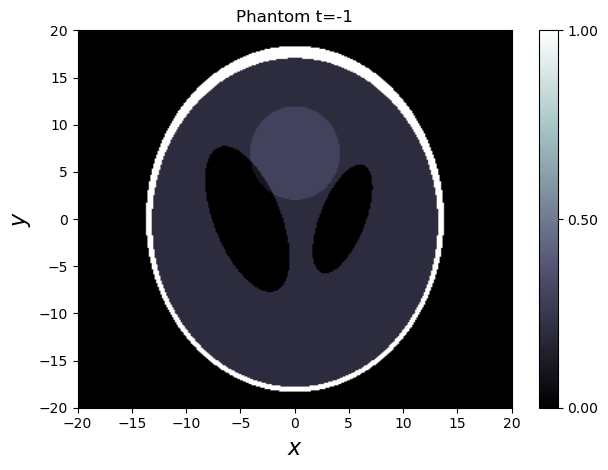

<Figure size 640x480 with 0 Axes>

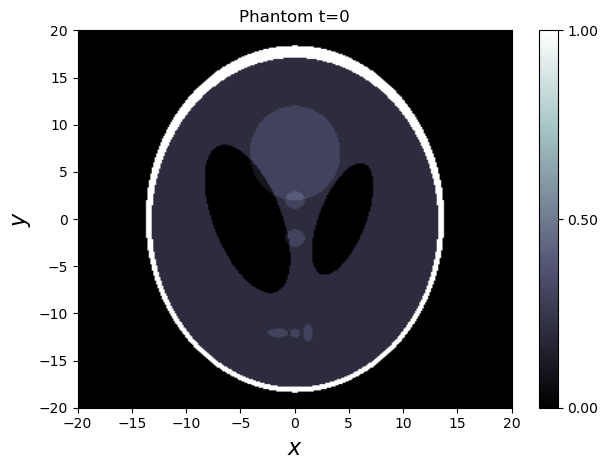

<Figure size 640x480 with 0 Axes>

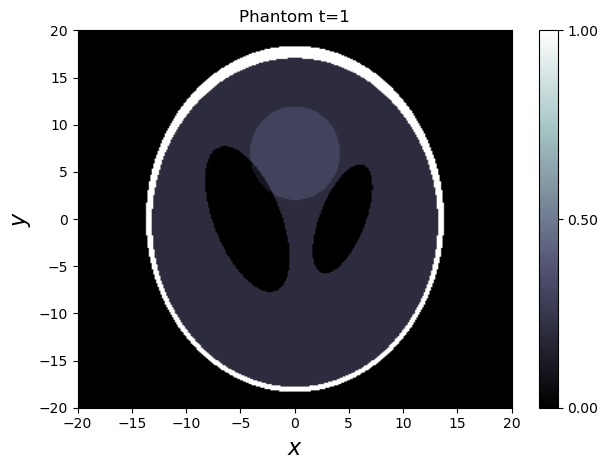

<Figure size 640x480 with 0 Axes>

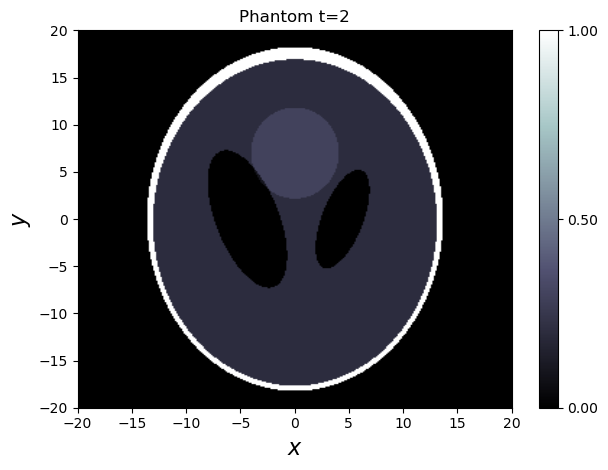

<Figure size 640x480 with 0 Axes>

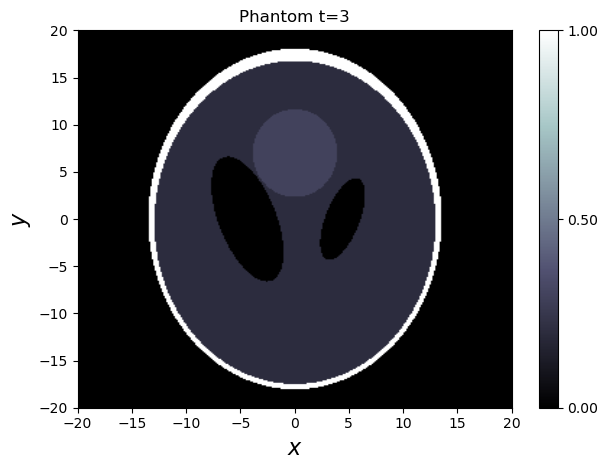

<Figure size 640x480 with 0 Axes>

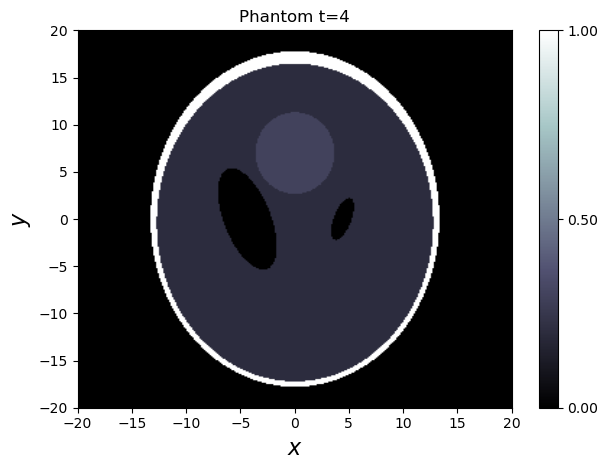

<Figure size 640x480 with 0 Axes>

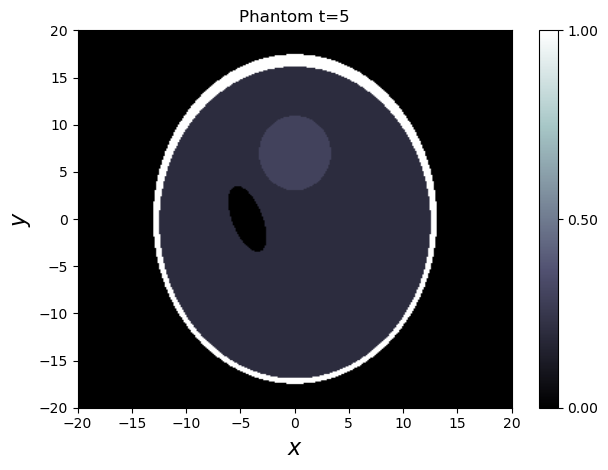

<Figure size 640x480 with 0 Axes>

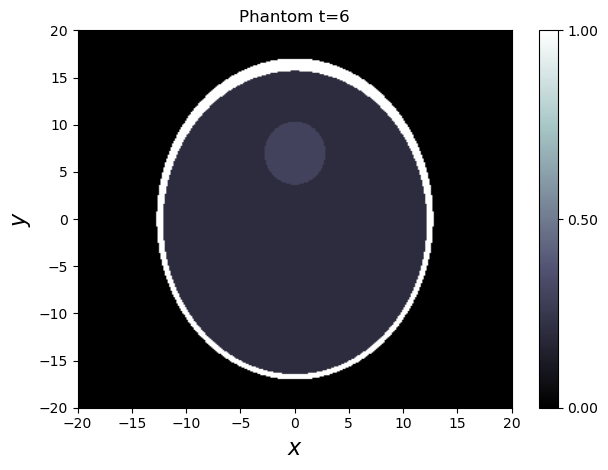

<Figure size 640x480 with 0 Axes>

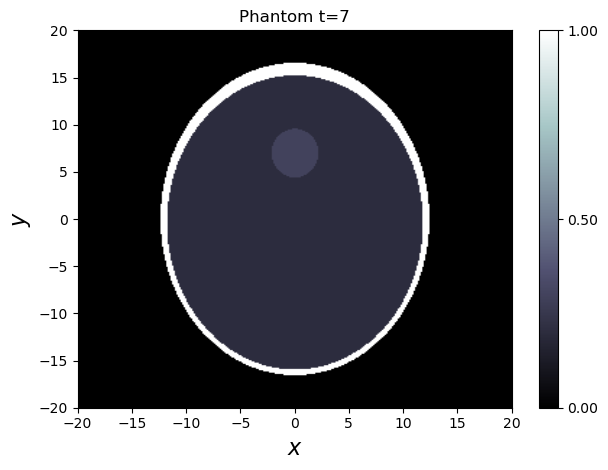

<Figure size 640x480 with 0 Axes>

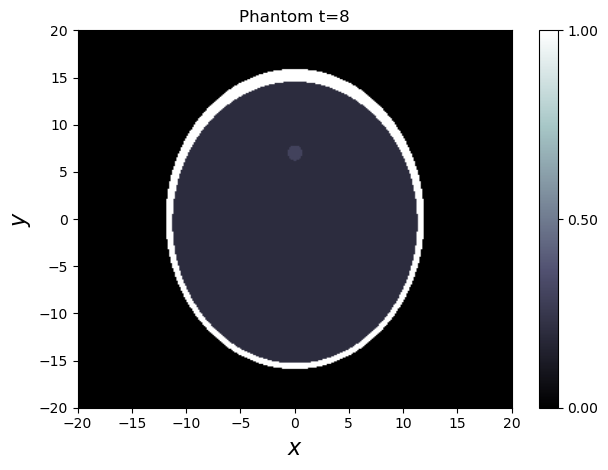

<Figure size 640x480 with 0 Axes>

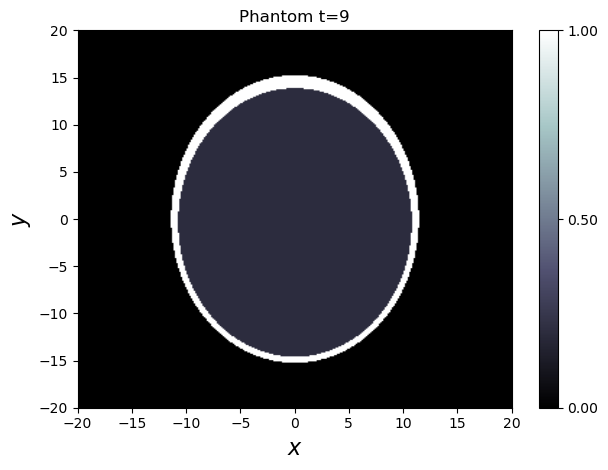

<Figure size 640x480 with 0 Axes>

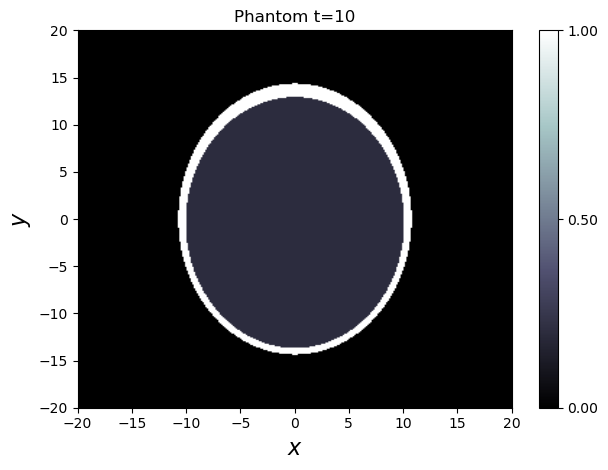

<Figure size 640x480 with 0 Axes>

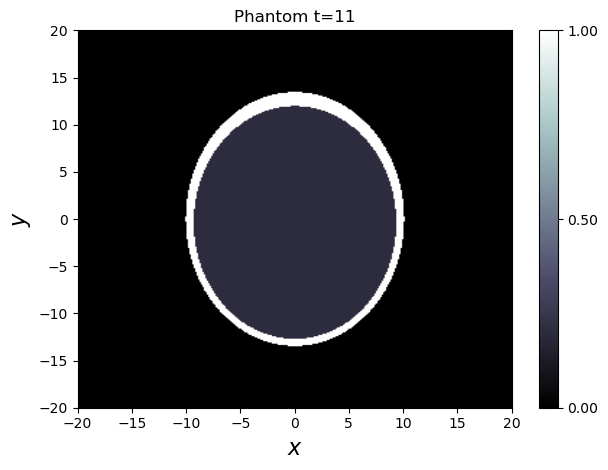

<Figure size 640x480 with 0 Axes>

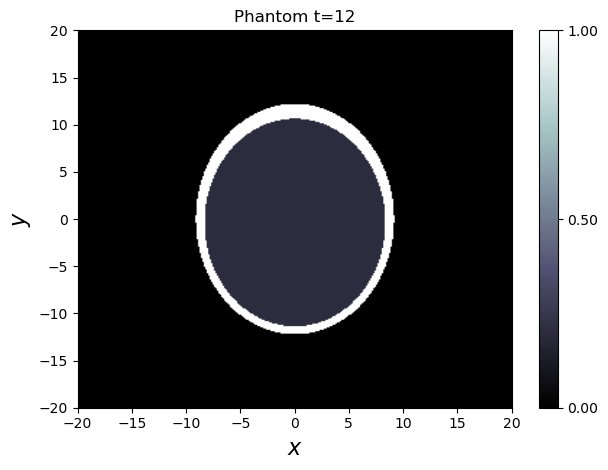

<Figure size 640x480 with 0 Axes>

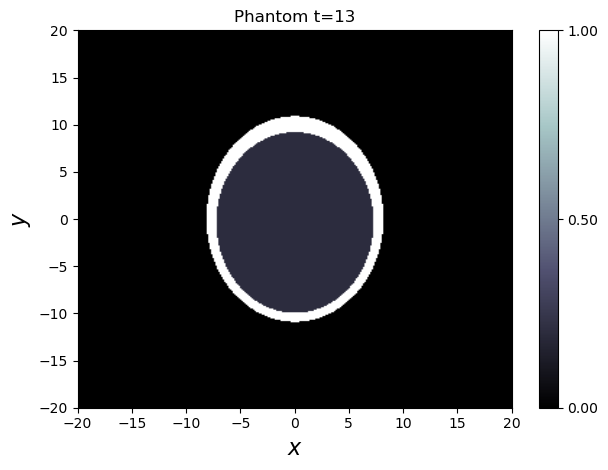

<Figure size 640x480 with 0 Axes>

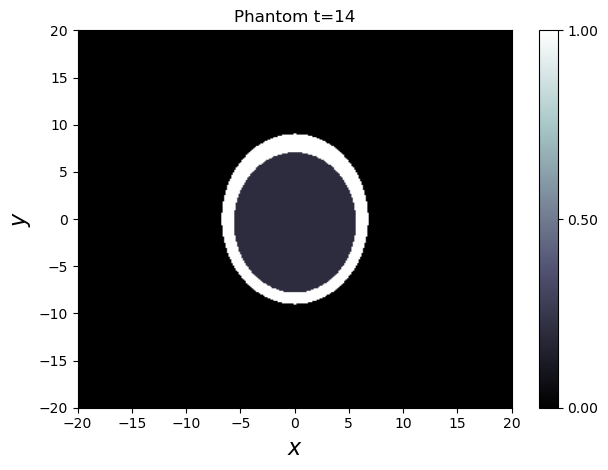

<Figure size 640x480 with 0 Axes>

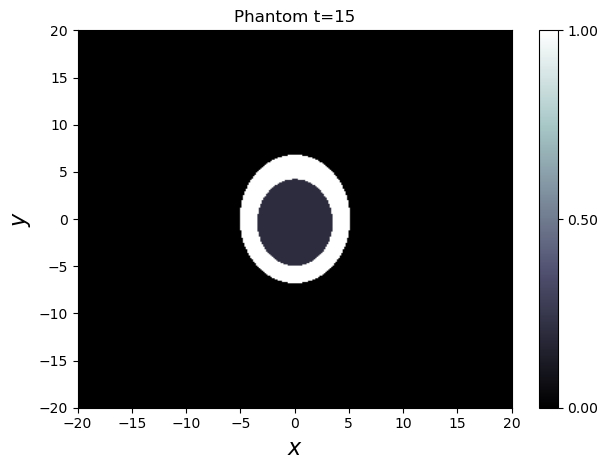

<Figure size 640x480 with 0 Axes>

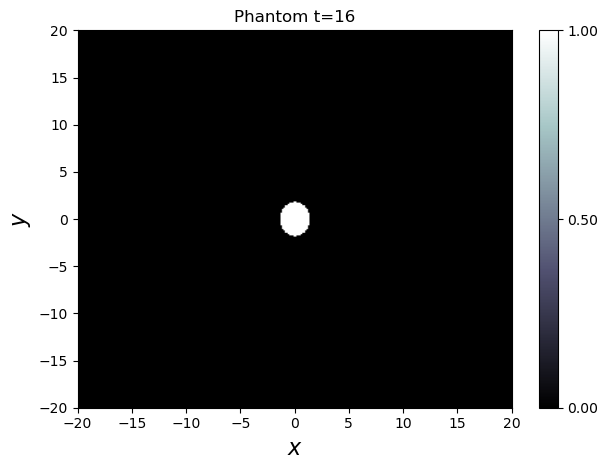

<Figure size 640x480 with 0 Axes>

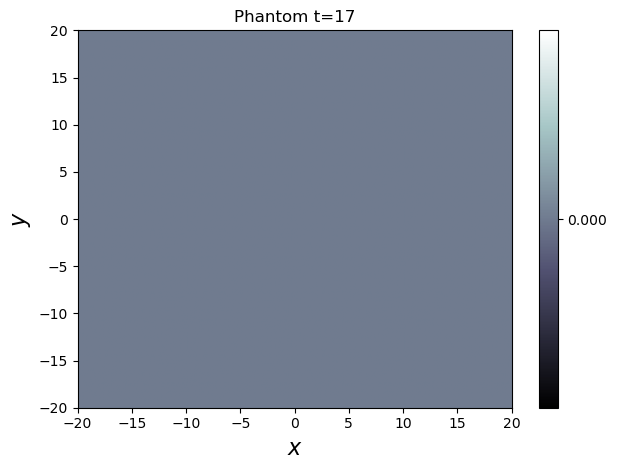

<Figure size 640x480 with 0 Axes>

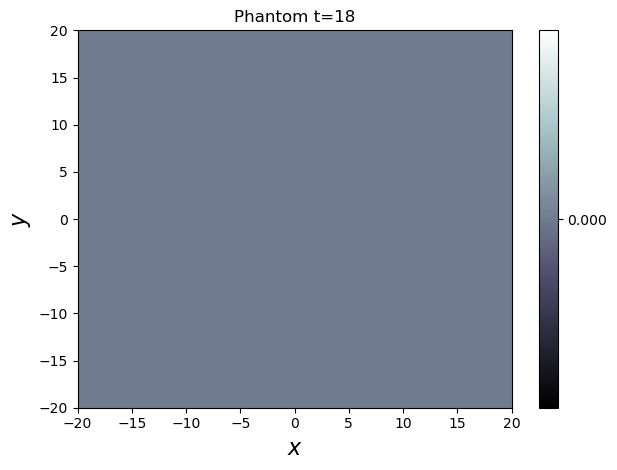

<Figure size 640x480 with 0 Axes>

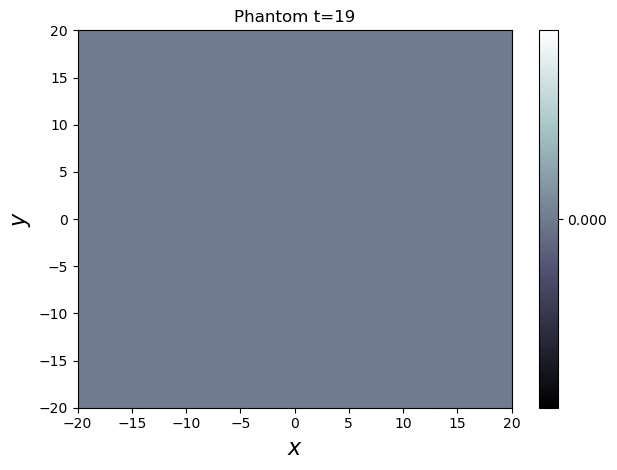

<Figure size 640x480 with 0 Axes>

In [32]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
phantom.show(coords=[None, 2, None], title='Phantom')
phantom.shape

frames = []

for t in range(-20, 20):
    fig = phantom.show(coords=[None, None, t], title=f'Phantom t={t}')
    fig.canvas.draw()

    # Obtener la imagen del canvas (nuevo método)
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    image = image[:, :, :3]  # quitar canal alfa

    frames.append(image)
    plt.close(fig)

In [10]:
# Create projection data by calling the ray transform on the phantom
proj_data = ray_trafo(phantom)

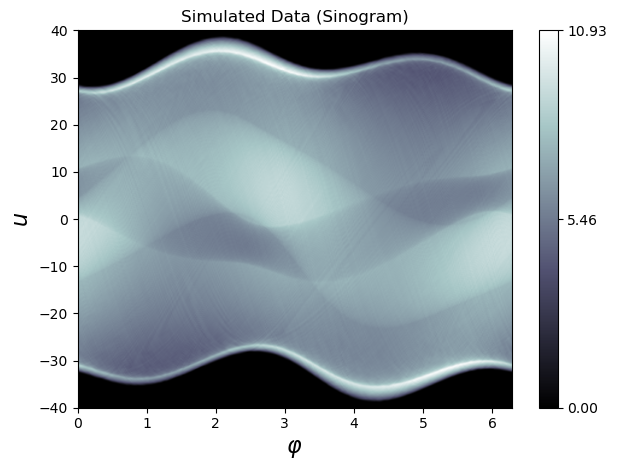

<Figure size 640x480 with 0 Axes>

(360, 512, 512)

In [14]:
proj_data.show(coords=[None, None, 10],title='Simulated Data (Sinogram)')
proj_data.shape

In [ ]:
# Calculate filtered back-projection of data
fbp_reconstruction = fbp(proj_data)

In [ ]:
# Shows a slice of the phantom, projections, and reconstruction
phantom.show(title='Phantom')
proj_data.show(title='Simulated Data (Sinogram)')
fbp_reconstruction.show(title='Filtered Back-projection')
(phantom - fbp_reconstruction).show(title='Error', force_show=True)